<a href="https://colab.research.google.com/github/KrasnovaOV/A-B-test/blob/main/%D0%90%D0%92_%D0%B8%D0%BD%D1%82%D0%B5%D1%80%D0%BF%D1%80%D0%B5%D1%82%D0%B8%D1%80%D1%83%D0%B5%D0%BC_%D0%B2%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%B7%D0%B8%D1%80%D1%83%D0%B5%D0%BC_%D1%80%D0%B5%D0%B7%D1%83%D0%BB%D1%8C%D1%82%D0%B0%D1%82%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Самостоятельное задание: интерпретируем и визуализируем результаты***

**Задание**

Воспользуйтесь тестовым датасетом и выполните вычисления для четырёх параметров: hour, distance, age и order_class.

**Расчёты:**

 - Для параметров hour, distance и age:
· найдите среднее;
· просчитайте медиану;
· вычислите дисперсию.

- Для параметра orderclass определите моду.
Визуализация: для параметров hour, distance и age постройте гистограмму.
Интерпретация результата: на основе графика определите, к какому типу распределения относятся данные.

Инструкция по выполнению:
Вы можете производить вычисления в любом из двух инструментов: Excel или Python.
- Шаг 1. Скачайте и импортируйте тестовый датасет.
Для Excel: скачайте файл и работайте прямо в нём.
Для Python: скачайте и импортируйте файл.
- Шаг 2. Найдите среднее
- Шаг 3. Просчитайте медиану
Вспомните, что медиана — значение, которое делит упорядоченные данные ровно пополам.
- Шаг 4. Определите моду
Вспомните, что мода — значение, которое встречается чаще всего в наборе данных.
- Шаг 5. Вычислите дисперсию
Вспомните, что дисперсия — мера разброса значений данных относительно их среднего (математического ожидания).
- Шаг 6. Постройте гистограмму
Гистограмма — это график, который показывает частотное распределение значений. Гистограмма помогает визуально оценить форму распределения.
Воспользуйтесь любым удобным вариантом.
- Шаг 7. Определите тип распределения

Тип распределения описывает, как значения распределены по оси. Чтобы определить тип распределения, учитывайте:
Визуальную форму гистограммы:
· Симметричная кривая (похожа на колокол) — нормальное распределение.
· Резко убывающая кривая с длинным хвостом вправо — экспоненциальное распределение.
· Скошенная кривая с длинным хвостом и плавным убыванием — асимметричное распределение.
· Два пика — бимодальное распределение.
· Несколько пиков — многомодальное распределение.
Положение средней, медианы и моды:
· Если они примерно совпадают — распределение ближе к нормальному.
· Если среднее сильно отличается от медианы — вероятна асимметрия.
Важно! Помните про наличие выбросов: они могут искажать распределение.

In [1]:
# Установка и импорт необходимых библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Стиль графиков
sns.set_style('whitegrid')

**2. Загрузка датасета**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving new_dataframe.csv to new_dataframe.csv


In [3]:
# Загрузка датасета

df = pd.read_csv('new_dataframe.csv')

# Первые пять строк
display(df.head())

,Unnamed: 0,user_id,hour,os,order_class,surge,app_opened,price_seen,order_made,ride_completed,user_cancelled,city_center_order,distance,age,rfm
0,0,867689,12,iOS,business,no surge,1,1,1,1,0,0,7.9821,20,low
1,1,752172,5,Android,economy,no surge,1,1,1,1,0,1,2.9085,27,high
2,2,486559,15,Android,comfort,no surge,1,1,1,1,0,0,7.2246,21,high
3,3,304024,0,Android,economy,no surge,1,1,1,1,0,1,1.8743,52,low
4,4,139420,0,Android,business,no surge,1,1,1,1,0,0,10.7048,19,low


**3. Первичный анализ данных**

In [4]:
# Размер датасета
print(f'Количество строк: {df.shape[0]}')
print(f'Количество столбцов: {df.shape[1]}')

# Названия столбцов
print('\nНазвания столбцов:')
print(df.columns.tolist())

# Типы данных
print('\nТипы данных:')
display(df.dtypes)

# Количество пропусков
print('\nКоличество пропусков:')
display(df[['hour', 'distance', 'age', 'order_class']].isna().sum())

Количество строк: 101500
Количество столбцов: 15

Названия столбцов:
['Unnamed: 0', 'user_id', 'hour', 'os', 'order_class', 'surge', 'app_opened', 'price_seen', 'order_made', 'ride_completed', 'user_cancelled', 'city_center_order', 'distance', 'age', 'rfm']

Типы данных:


,0
Unnamed: 0,int64
user_id,int64
hour,int64
os,object
order_class,object
surge,object
app_opened,int64
price_seen,int64
order_made,int64
ride_completed,int64



Количество пропусков:


,0
hour,0
distance,10069
age,0
order_class,0


In [5]:
print("""
Интерпретация:

В датасете содержатся данные о времени заказа, расстоянии поездки,
возрасте пользователя и классе заказа.

Перед расчётами необходимо учитывать пропущенные значения.
Для числовых параметров пропуски будут автоматически исключены
при вычислении статистик.
""")


Интерпретация:

В датасете содержатся данные о времени заказа, расстоянии поездки,
возрасте пользователя и классе заказа.

Перед расчётами необходимо учитывать пропущенные значения.
Для числовых параметров пропуски будут автоматически исключены
при вычислении статистик.



**4. Подготовка параметров**

In [6]:
# Числовые параметры для анализа
numeric_columns = ['hour', 'distance', 'age']

# Категориальный параметр
categorical_column = 'order_class'

# Преобразование числовых столбцов в числовой формат
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

print('Параметры для анализа:')
print(f'Числовые: {numeric_columns}')
print(f'Категориальный: {categorical_column}')

Параметры для анализа:
Числовые: ['hour', 'distance', 'age']
Категориальный: order_class


**5. Расчёт среднего значения, медианы и дисперсии**

In [7]:
statistics = []

for column in numeric_columns:
    series = df[column].dropna()

    statistics.append({
        'Параметр': column,
        'Количество значений': series.count(),
        'Среднее': series.mean(),
        'Медиана': series.median(),
        'Выборочная дисперсия': series.var(ddof=1),
        'Генеральная дисперсия': series.var(ddof=0),
        'Минимум': series.min(),
        'Максимум': series.max()
    })

statistics_df = pd.DataFrame(statistics)

display(statistics_df)

,Параметр,Количество значений,Среднее,Медиана,Выборочная дисперсия,Генеральная дисперсия,Минимум,Максимум
0,hour,101500,11.4814,11.0000,47.8521,47.8516,0.0000,23.0000
1,distance,91431,5.3712,4.2796,16.9623,16.9621,0.0109,40.2690
2,age,101500,25.9064,24.0000,61.4394,61.4388,18.0000,69.0000


In [8]:
for _, row in statistics_df.iterrows():
    column = row['Параметр']
    mean_value = row['Среднее']
    median_value = row['Медиана']

    difference = mean_value - median_value

    print(f'\nПараметр: {column}')
    print(f'Среднее значение: {mean_value:.2f}')
    print(f'Медиана: {median_value:.2f}')
    print(f'Выборочная дисперсия: {row["Выборочная дисперсия"]:.2f}')

    if abs(difference) < 0.1:
        print('Интерпретация: среднее и медиана почти совпадают.')
        print('Распределение может быть близким к симметричному.')
    elif difference > 0:
        print('Интерпретация: среднее больше медианы.')
        print('Распределение, вероятно, имеет правую асимметрию.')
    else:
        print('Интерпретация: среднее меньше медианы.')
        print('Распределение, вероятно, имеет левую асимметрию.')


Параметр: hour
Среднее значение: 11.48
Медиана: 11.00
Выборочная дисперсия: 47.85
Интерпретация: среднее больше медианы.
Распределение, вероятно, имеет правую асимметрию.

Параметр: distance
Среднее значение: 5.37
Медиана: 4.28
Выборочная дисперсия: 16.96
Интерпретация: среднее больше медианы.
Распределение, вероятно, имеет правую асимметрию.

Параметр: age
Среднее значение: 25.91
Медиана: 24.00
Выборочная дисперсия: 61.44
Интерпретация: среднее больше медианы.
Распределение, вероятно, имеет правую асимметрию.


**6. Расчёт моды order_class**

In [9]:
# Частоты значений order_class
order_class_counts = df['order_class'].value_counts(dropna=False)

print('Частота классов заказов:')
display(order_class_counts.to_frame(name='Количество'))

# Мода
order_class_mode = df['order_class'].mode()

print('Мода параметра order_class:')
print(order_class_mode.tolist())

Частота классов заказов:


,Количество
order_class,
economy,47219
comfort,42248
business,12033


Мода параметра order_class:
['economy']


In [10]:
mode_value = order_class_mode.iloc[0]
mode_frequency = order_class_counts[mode_value]

print(
    f'Наиболее часто встречающийся класс заказа — "{mode_value}". '
    f'Он встречается {mode_frequency} раз.'
)

Наиболее часто встречающийся класс заказа — "economy". Он встречается 47219 раз.


**7. Построение гистограмм**

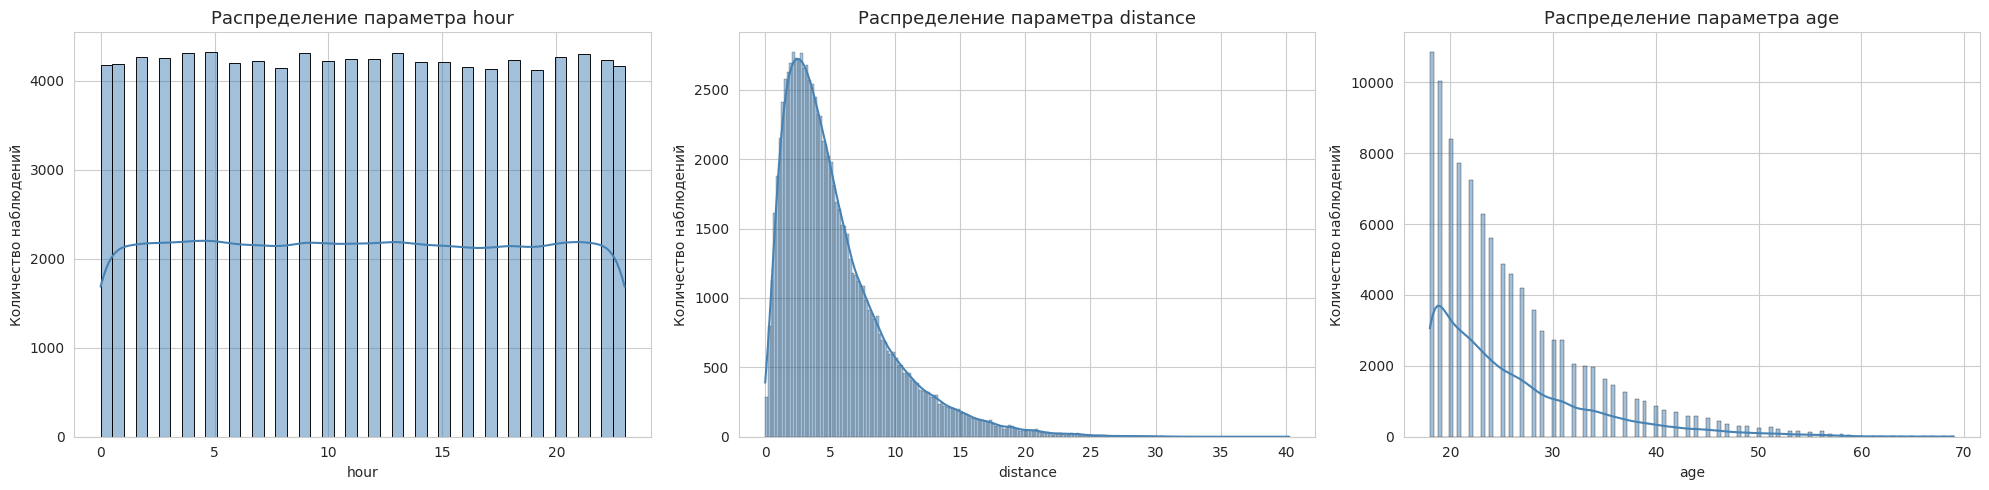

In [11]:
# Построение гистограмм для hour, distance и age

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, column in zip(axes, numeric_columns):
    sns.histplot(
        data=df,
        x=column,
        bins='auto',
        kde=True,
        color='steelblue',
        edgecolor='black',
        ax=ax
    )

    ax.set_title(f'Распределение параметра {column}', fontsize=13)
    ax.set_xlabel(column)
    ax.set_ylabel('Количество наблюдений')

plt.tight_layout()
plt.show()

**8. Анализ формы распределений**

In [12]:
# Дополнительный анализ асимметрии

distribution_analysis = []

for column in numeric_columns:
    series = df[column].dropna()

    skewness = series.skew()
    mean_value = series.mean()
    median_value = series.median()

    if abs(skewness) < 0.2:
        distribution_type = 'примерно симметричное распределение'
    elif skewness >= 0.2 and skewness < 1:
        distribution_type = 'умеренная правая асимметрия'
    elif skewness >= 1:
        distribution_type = 'сильная правая асимметрия'
    elif skewness <= -1:
        distribution_type = 'сильная левая асимметрия'
    else:
        distribution_type = 'умеренная левая асимметрия'

    distribution_analysis.append({
        'Параметр': column,
        'Асимметрия': skewness,
        'Среднее': mean_value,
        'Медиана': median_value,
        'Предполагаемый тип распределения': distribution_type
    })

distribution_analysis_df = pd.DataFrame(distribution_analysis)

display(distribution_analysis_df)

,Параметр,Асимметрия,Среднее,Медиана,Предполагаемый тип распределения
0,hour,0.0065,11.4814,11.0000,примерно симметричное распределение
1,distance,1.6191,5.3712,4.2796,сильная правая асимметрия
2,age,1.5200,25.9064,24.0000,сильная правая асимметрия


**Текстовая интерпретация распределений**

In [13]:
for _, row in distribution_analysis_df.iterrows():
    column = row['Параметр']
    skewness = row['Асимметрия']

    print(f'\n{column}:')

    if abs(skewness) < 0.2:
        print(
            'Гистограмма должна быть близка к симметричной. '
            'Распределение можно считать примерно симметричным.'
        )
    elif skewness >= 0.2:
        print(
            'На гистограмме наблюдается правый хвост. '
            'Распределение является асимметричным вправо.'
        )
    else:
        print(
            'На гистограмме наблюдается левый хвост. '
            'Распределение является асимметричным влево.'
        )


hour:
Гистограмма должна быть близка к симметричной. Распределение можно считать примерно симметричным.

distance:
На гистограмме наблюдается правый хвост. Распределение является асимметричным вправо.

age:
На гистограмме наблюдается правый хвост. Распределение является асимметричным вправо.


**9. Отдельные графики со средними линиями и медианами**

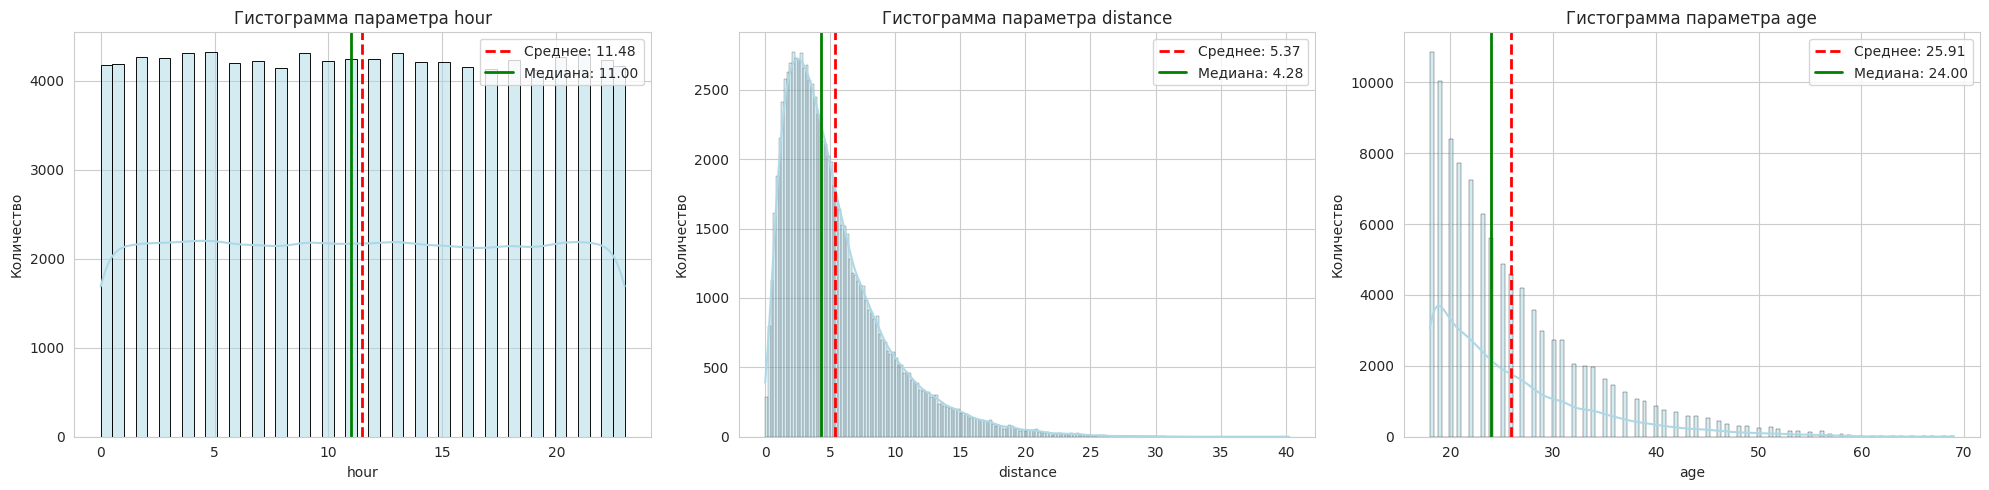

In [14]:
# Гистограммы с обозначением среднего и медианы

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, column in zip(axes, numeric_columns):
    series = df[column].dropna()

    sns.histplot(
        series,
        bins='auto',
        kde=True,
        color='lightblue',
        edgecolor='black',
        ax=ax
    )

    mean_value = series.mean()
    median_value = series.median()

    ax.axvline(
        mean_value,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Среднее: {mean_value:.2f}'
    )

    ax.axvline(
        median_value,
        color='green',
        linestyle='-',
        linewidth=2,
        label=f'Медиана: {median_value:.2f}'
    )

    ax.set_title(f'Гистограмма параметра {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Количество')
    ax.legend()

plt.tight_layout()
plt.show()

**10. Итоговый вывод**

In [15]:
print("""
ИТОГОВЫЙ ВЫВОД

1. Для параметров hour, distance и age были рассчитаны:
   - среднее значение;
   - медиана;
   - выборочная дисперсия.

2. Модой параметра order_class является класс economy,
   то есть он встречается чаще всего.

3. Параметр hour распределён по часам и визуально может быть
   близок к равномерному или дискретному распределению.

4. Параметр distance обычно имеет правую асимметрию:
   большинство поездок короткие, а небольшое количество длинных
   поездок формирует правый хвост.

5. Параметр age также может иметь правую асимметрию:
   среднее значение больше медианы, поскольку отдельные значения
   старшего возраста увеличивают среднее.

6. Если среднее больше медианы, это является признаком правой
   асимметрии. При интерпретации также необходимо учитывать
   выбросы и пропущенные значения.
""")


ИТОГОВЫЙ ВЫВОД

1. Для параметров hour, distance и age были рассчитаны:
   - среднее значение;
   - медиана;
   - выборочная дисперсия.

2. Модой параметра order_class является класс economy,
   то есть он встречается чаще всего.

3. Параметр hour распределён по часам и визуально может быть
   близок к равномерному или дискретному распределению.

4. Параметр distance обычно имеет правую асимметрию:
   большинство поездок короткие, а небольшое количество длинных
   поездок формирует правый хвост.

5. Параметр age также может иметь правую асимметрию:
   среднее значение больше медианы, поскольку отдельные значения
   старшего возраста увеличивают среднее.

6. Если среднее больше медианы, это является признаком правой
   асимметрии. При интерпретации также необходимо учитывать
   выбросы и пропущенные значения.



**11. Сохранение результатов**

In [16]:
# Сохранение таблицы статистик
statistics_df.to_csv(
    'statistics_results.csv',
    index=False,
    encoding='utf-8-sig'
)

# Сохранение частот order_class
order_class_counts.to_csv(
    'order_class_frequency.csv',
    header=['Количество'],
    encoding='utf-8-sig'
)

# Скачивание файлов из Google Colab
from google.colab import files

files.download('statistics_results.csv')
files.download('order_class_frequency.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Установка библиотеки для записи Excel-файлов
!pip install openpyxl -q

In [18]:
# Сохранение результатов в Excel-файл

excel_filename = 'analysis_results.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Основная статистика:
    # среднее, медиана, дисперсия, минимум и максимум
    statistics_df.to_excel(
        writer,
        sheet_name='Статистика',
        index=False
    )

    # Частоты классов заказов
    order_class_counts.rename(
        'Количество'
    ).reset_index().rename(
        columns={'index': 'order_class'}
    ).to_excel(
        writer,
        sheet_name='Классы заказов',
        index=False
    )

    # Анализ типа распределения и асимметрии
    distribution_analysis_df.to_excel(
        writer,
        sheet_name='Распределения',
        index=False
    )

print(f'Excel-файл "{excel_filename}" успешно создан.')

Excel-файл "analysis_results.xlsx" успешно создан.


**Сохранение в pdf**

In [19]:
# Установка библиотеки для работы с PDF
!pip install reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.0 MB/s eta 0:00:00


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

# Загрузка датасета
df = pd.read_csv('new_dataframe.csv')

# Параметры анализа
numeric_columns = ['hour', 'distance', 'age']

# Преобразование числовых столбцов
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Расчёт статистик
statistics = []

for column in numeric_columns:
    series = df[column].dropna()

    statistics.append({
        'Параметр': column,
        'Количество значений': series.count(),
        'Среднее': series.mean(),
        'Медиана': series.median(),
        'Выборочная дисперсия': series.var(ddof=1),
        'Генеральная дисперсия': series.var(ddof=0),
        'Минимум': series.min(),
        'Максимум': series.max()
    })

statistics_df = pd.DataFrame(statistics)

# Расчёт моды и частот order_class
order_class_counts = df['order_class'].value_counts(dropna=False)
order_class_mode = df['order_class'].mode().iloc[0]

# Анализ формы распределения
distribution_analysis = []

for column in numeric_columns:
    series = df[column].dropna()
    skewness = series.skew()

    if abs(skewness) < 0.2:
        distribution_type = 'примерно симметричное'
    elif skewness > 0:
        distribution_type = 'асимметричное вправо'
    else:
        distribution_type = 'асимметричное влево'

    distribution_analysis.append({
        'Параметр': column,
        'Коэффициент асимметрии': skewness,
        'Тип распределения': distribution_type
    })

distribution_analysis_df = pd.DataFrame(distribution_analysis)

In [21]:
# Имя итогового PDF-файла
pdf_filename = 'analysis_report.pdf'

with PdfPages(pdf_filename) as pdf:

    # -------------------------------------------------
    # Страница 1. Таблицы и текстовые выводы
    # -------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis('off')

    fig.text(
        0.05, 0.95,
        'Отчёт по статистическому анализу датасета',
        fontsize=20,
        fontweight='bold'
    )

    fig.text(
        0.05, 0.90,
        f'Количество строк в датасете: {len(df)}',
        fontsize=12
    )

    # Таблица статистик
    table_statistics = statistics_df.copy()

    numeric_result_columns = [
        'Среднее',
        'Медиана',
        'Выборочная дисперсия',
        'Генеральная дисперсия',
        'Минимум',
        'Максимум'
    ]

    for column in numeric_result_columns:
        table_statistics[column] = table_statistics[column].round(4)

    table_statistics['Количество значений'] = (
        table_statistics['Количество значений'].astype(int)
    )

    fig.text(
        0.05, 0.84,
        '1. Основные статистические показатели',
        fontsize=15,
        fontweight='bold'
    )

    ax_table_1 = fig.add_axes([0.05, 0.60, 0.90, 0.20])
    ax_table_1.axis('off')

    table_1 = ax_table_1.table(
        cellText=table_statistics.values,
        colLabels=table_statistics.columns,
        loc='center',
        cellLoc='center'
    )

    table_1.auto_set_font_size(False)
    table_1.set_fontsize(8)
    table_1.scale(1, 1.8)

    # Мода order_class
    fig.text(
        0.05, 0.54,
        '2. Мода параметра order_class',
        fontsize=15,
        fontweight='bold'
    )

    fig.text(
        0.07, 0.50,
        f'Мода: {order_class_mode}',
        fontsize=12
    )

    fig.text(
        0.07, 0.46,
        f'Количество заказов класса {order_class_mode}: '
        f'{order_class_counts[order_class_mode]}',
        fontsize=12
    )

    # Таблица частот order_class
    class_table = (
        order_class_counts
        .rename('Количество')
        .reset_index()
    )

    class_table.columns = ['Класс заказа', 'Количество']

    ax_table_2 = fig.add_axes([0.05, 0.28, 0.40, 0.15])
    ax_table_2.axis('off')

    table_2 = ax_table_2.table(
        cellText=class_table.values,
        colLabels=class_table.columns,
        loc='center',
        cellLoc='center'
    )

    table_2.auto_set_font_size(False)
    table_2.set_fontsize(10)
    table_2.scale(1, 1.5)

    # Типы распределений
    fig.text(
        0.52, 0.42,
        '3. Интерпретация распределений',
        fontsize=15,
        fontweight='bold'
    )

    y_position = 0.37

    for _, row in distribution_analysis_df.iterrows():
        text = (
            f"{row['Параметр']}: {row['Тип распределения']}; "
            f"асимметрия = {row['Коэффициент асимметрии']:.4f}"
        )

        fig.text(
            0.54,
            y_position,
            text,
            fontsize=10
        )

        y_position -= 0.06

    # Общий вывод
    fig.text(
        0.05, 0.20,
        '4. Общий вывод',
        fontsize=15,
        fontweight='bold'
    )

    conclusion = (
        'Для параметров hour, distance и age рассчитаны среднее, '
        'медиана и дисперсия. Модой order_class является economy. '
        'Если среднее значение больше медианы, распределение имеет '
        'правую асимметрию. Пропущенные значения исключены из расчётов.'
    )

    fig.text(
        0.07, 0.13,
        conclusion,
        fontsize=10,
        wrap=True
    )

    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # -------------------------------------------------
    # Страница 2. Гистограммы
    # -------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    for ax, column in zip(axes, numeric_columns):
        series = df[column].dropna()

        ax.hist(
            series,
            bins='auto',
            color='steelblue',
            edgecolor='black',
            alpha=0.8
        )

        ax.axvline(
            series.mean(),
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Среднее: {series.mean():.2f}'
        )

        ax.axvline(
            series.median(),
            color='green',
            linestyle='-',
            linewidth=2,
            label=f'Медиана: {series.median():.2f}'
        )

        ax.set_title(f'Гистограмма: {column}')
        ax.set_xlabel(column)
        ax.set_ylabel('Количество наблюдений')
        ax.legend(fontsize=8)

    fig.suptitle(
        'Гистограммы числовых параметров',
        fontsize=16,
        fontweight='bold'
    )

    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # -------------------------------------------------
    # Страница 3. Частоты order_class
    # -------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 5))

    order_class_counts.plot(
        kind='bar',
        color=['steelblue', 'orange', 'seagreen'],
        edgecolor='black',
        ax=ax
    )

    ax.set_title(
        'Распределение классов заказов',
        fontsize=15,
        fontweight='bold'
    )

    ax.set_xlabel('Класс заказа')
    ax.set_ylabel('Количество заказов')
    ax.tick_params(axis='x', rotation=0)

    for index, value in enumerate(order_class_counts):
        ax.text(
            index,
            value + value * 0.01,
            str(value),
            ha='center',
            fontsize=10
        )

    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

print(f'PDF-файл "{pdf_filename}" успешно создан.')

PDF-файл "analysis_report.pdf" успешно создан.
